# Single-Example BrushNet Comparison

This notebook runs the same four implementations as the resumable BrushBench evaluation. Every method receives the same source, mask, prompt, and independent initial latent tensor.

In [1]:
from dataclasses import replace
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Set these paths before importing the inpainting modules.
BRUSHNET_ROOT = Path(os.environ.get(
    'BRUSHNET_ROOT',
    Path.home() / 'BrushNet',
))


# 
os.environ.setdefault('BRUSHNET_ROOT', str(BRUSHNET_ROOT))
os.environ.setdefault('BRUSHNET_BASE_MODEL', str(BRUSHNET_ROOT / 'checkpoints' / 'stable-diffusion-xl-base-1.0'))
os.environ.setdefault('BRUSHNET_MODEL', str(BRUSHNET_ROOT / 'checkpoints' / 'brushnet_sdxl'))
os.environ.setdefault('BRUSHBENCH_ROOT', str(ROOT / 'BrushBench'))
os.environ['BRUSHNET_MODEL_FAMILY'] = 'sdxl'

# os.environ['BRUSHNET_BASE_MODEL'] = (
#     'stabilityai/stable-diffusion-xl-base-1.0'
# )

# os.environ['BRUSHNET_MODEL'] = str(
#     BRUSHNET_ROOT / 'checkpoints' / 'brushnet_sdxl'
# )
EXAMPLE_KEY = '000000043'
SELECTED_METHODS = ['clean_ddim', 'cads', 'rho_star_pullback', 'tpso']
# SELECTED_METHODS = ['clean_ddim', 'tpso']
RESPONSE_REGION = 'edit_mask'  # use 'edit_mask' for the regional operator

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from configs.inpainting import EXPERIMENT
from evaluation.inpainting_metrics import InpaintingMetrics
from inpainting import data, experiment, model

config = replace(EXPERIMENT, pullback_response_region=RESPONSE_REGION)
pipe = model.load_pipeline()
example = data.load_example(EXAMPLE_KEY)
sample = experiment.prepare_example(pipe, example, config)
metrics = InpaintingMetrics(device=str(pipe._execution_device))
print(example.key, example.prompt)
print('initial latents:', tuple(sample.initial_latents.shape))

/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dehay/BrushNet/src/diffusers/models/lora.py:387: FutureWarning: `LoRACompatibleLinear` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleLinear` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleLinear", "1.0.0", deprecation_message)
/home/dehay/BrushNet/src/diffusers/models/lora.py:300: FutureWarning: `LoRACompatibleConv` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleConv` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleConv", "1.0.0", deprecation_message)
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.83it/s]


000000043 a small rabbit with big eyes and a smile
initial latents: (5, 4, 128, 128)


## Prepare Method-Specific State

The pullback method computes its basis once before the shared sampler restarts. TPSO optimizes its token offsets before sampling.

In [3]:
basis = None
eigenvalues = None
optimized_tpso = None

if 'adaptive_pullback' in SELECTED_METHODS or 'rho_star_pullback' in SELECTED_METHODS:
    basis, eigenvalues = experiment.compute_initial_basis(
        pipe, sample, config, cache_dir=ROOT / 'outputs' / 'notebook_basis_cache'
    )
    print('pullback eigenvalues:', [round(float(x), 4) for x in eigenvalues[:8]])

if 'tpso' in SELECTED_METHODS:
    optimized_tpso = experiment.optimize_tpso(pipe, sample, config)
    print('TPSO steps:', optimized_tpso.steps_run)

pullback eigenvalues: [0.3609, 0.1666, 0.065, 0.0506, 0.0433, 0.0367, 0.0353, 0.0313]
TPSO 001/200: joint=1.9500 clean_cos=1.0000 pair_cos=1.0000
TPSO 010/200: joint=0.6758 clean_cos=0.8020 pair_cos=0.6740
TPSO 020/200: joint=0.6070 clean_cos=0.7879 pair_cos=0.5927
TPSO 030/200: joint=0.5849 clean_cos=0.7937 pair_cos=0.5786
TPSO 040/200: joint=0.5657 clean_cos=0.7921 pair_cos=0.5634
TPSO 050/200: joint=0.5642 clean_cos=0.7862 pair_cos=0.5454
TPSO 060/200: joint=0.5566 clean_cos=0.7898 pair_cos=0.5473
TPSO 070/200: joint=0.5538 clean_cos=0.7896 pair_cos=0.5437
TPSO 080/200: joint=0.5485 clean_cos=0.7905 pair_cos=0.5436
TPSO 090/200: joint=0.5535 clean_cos=0.7921 pair_cos=0.5449
TPSO 100/200: joint=0.5449 clean_cos=0.7921 pair_cos=0.5437
TPSO 110/200: joint=0.5465 clean_cos=0.7915 pair_cos=0.5417
TPSO 120/200: joint=0.5518 clean_cos=0.7885 pair_cos=0.5354
TPSO 130/200: joint=0.5500 clean_cos=0.7872 pair_cos=0.5320
TPSO 140/200: joint=0.5525 clean_cos=0.7868 pair_cos=0.5310
TPSO 150/200: 

In [4]:
images_by_method = {}
raw_by_method = {}
tpso_alpha_trace = None
rho_star_details = None

for method_name in SELECTED_METHODS:
    if method_name == 'clean_ddim':
        raw, blended = experiment.run_clean_ddim(pipe, sample, config)
    elif method_name == 'cads':
        raw, blended = experiment.run_cads(pipe, sample, config)
    elif method_name == 'adaptive_pullback':
        raw, blended = experiment.run_adaptive_pullback(
            pipe, sample, basis, config
        )
    elif method_name == 'rho_star_pullback':
        raw, blended, rho_star_details = experiment.run_rho_star_pullback(
            pipe, sample, basis, config, metrics
        )
    elif method_name == 'tpso':
        raw, blended, tpso_alpha_trace = experiment.run_tpso(
            pipe, sample, optimized_tpso, config
        )
    else:
        raise ValueError(f'unknown method: {method_name}')
    raw_by_method[method_name] = raw
    images_by_method[method_name] = blended

/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


selected rhos: [2.25, 1.75, 2.0, 1.25, 1.5]
adaptive pullback refresh timesteps: [841, 661]


adaptive pullback:  14%|█▍        | 7/49 [00:10<01:02,  1.50s/it]

recomputing rank-10 pullback basis at t=841 from particle 0
intermediate pullback eigenvalues: ['0.0815', '0.0606', '0.0306', '0.0257', '0.011', '0.00877', '0.00755', '0.00593']


adaptive pullback:  33%|███▎      | 16/49 [00:28<00:48,  1.46s/it]

recomputing rank-10 pullback basis at t=661 from particle 0
intermediate pullback eigenvalues: ['0.418', '0.151', '0.0497', '0.0363', '0.0246', '0.0244', '0.0186', '0.0149']


/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/transformers/models/beit/image_processing_beit.py:108: FutureWarning: The `reduce_labels`

,method,lpips_mean,lpips_min,dino_sim_mean,dino_sim_max,vendi,clip,mss
0,clean_ddim,0.154028,0.140769,0.946867,0.957126,1.078438,30.867192,0.986226
1,cads,0.167223,0.149544,0.939514,0.949842,1.111077,30.706720,0.979478
2,rho_star_pullback,0.236946,0.185045,0.894341,0.925466,1.135443,30.420914,0.974426
3,tpso,0.186804,0.155421,0.931442,0.955736,1.095996,30.984096,0.982588


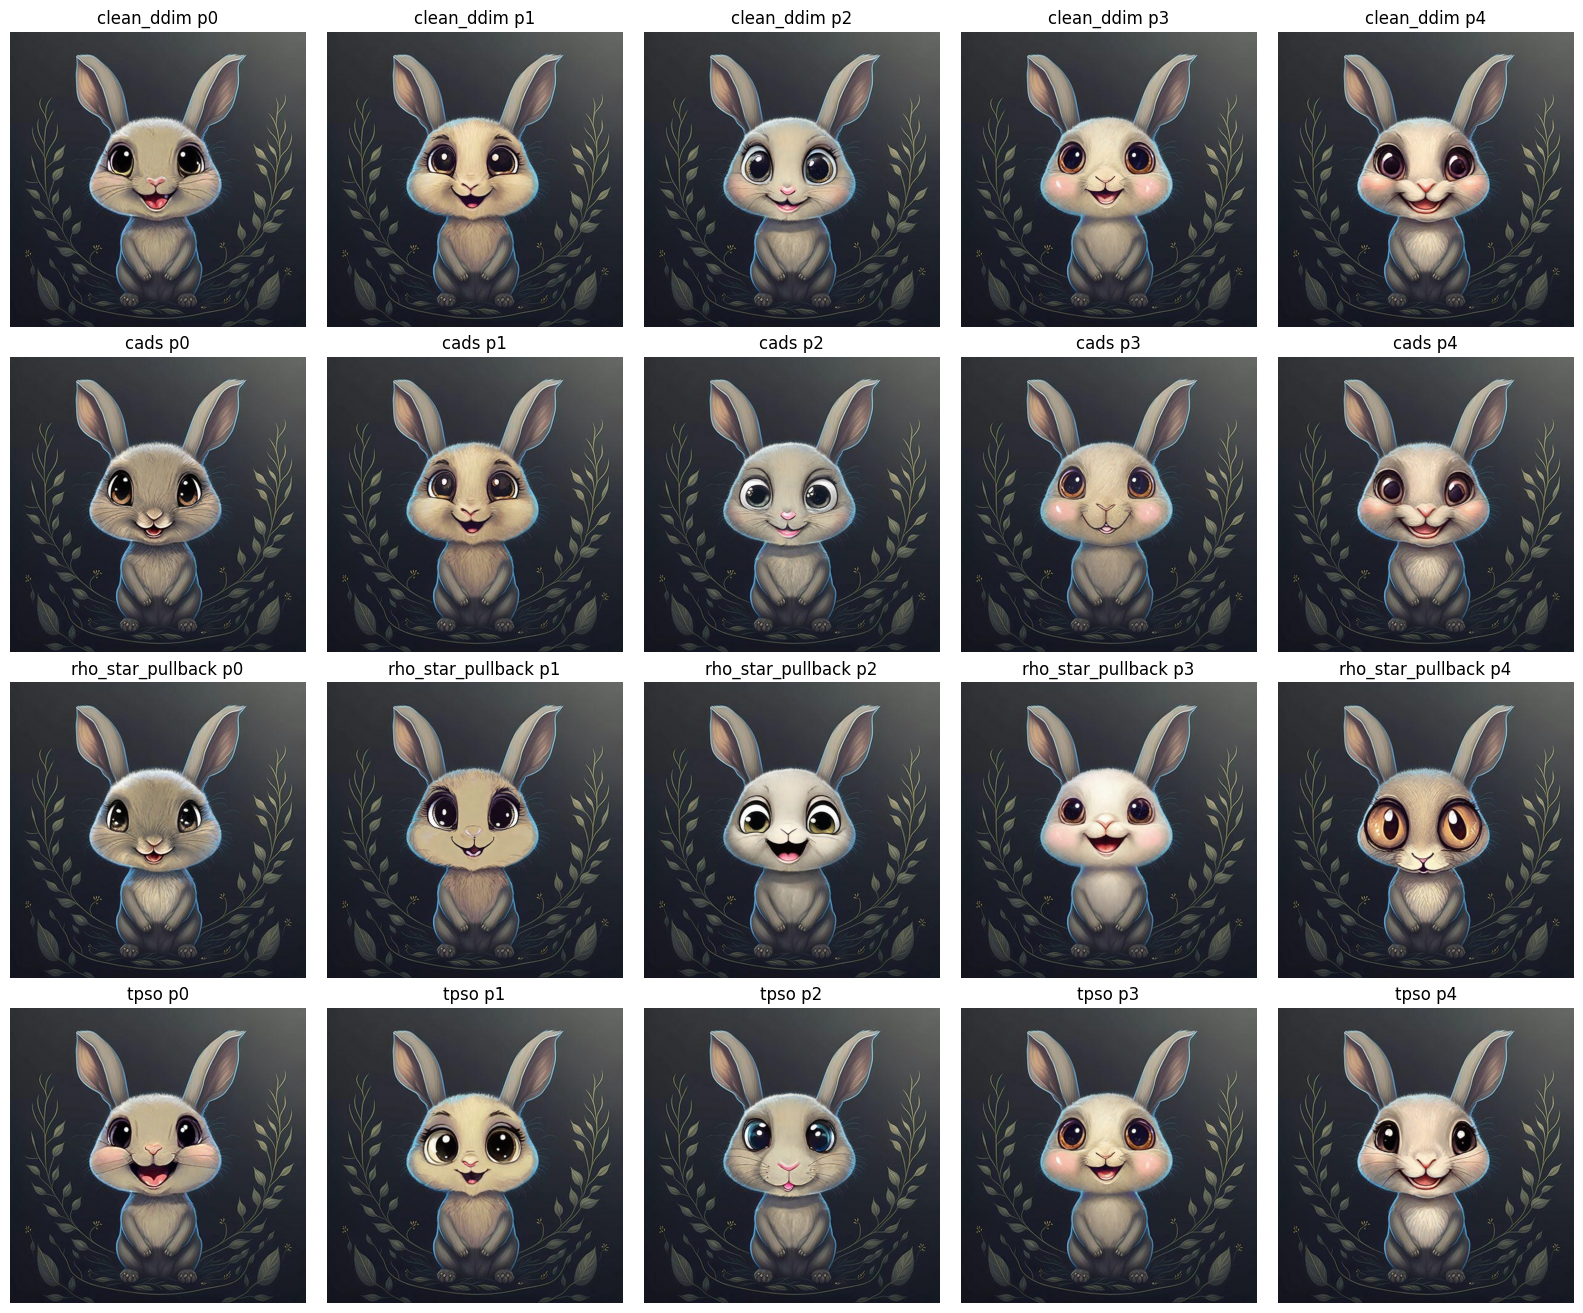

In [5]:
rows = []
for method_name, images in images_by_method.items():
    values = metrics.full_metrics(images, example.prompt, sample.edit_mask_image)
    rows.append({'method': method_name, **values})
display(pd.DataFrame(rows)[
    ['method', 'lpips_mean', 'lpips_min', 'dino_sim_mean',
     'dino_sim_max', 'vendi', 'clip', 'mss']
])

fig, axes = plt.subplots(
    len(images_by_method), config.num_particles,
    figsize=(3.2 * config.num_particles, 3.3 * len(images_by_method)),
    squeeze=False,
)
for row, (method_name, images) in enumerate(images_by_method.items()):
    for particle, image in enumerate(images):
        axes[row, particle].imshow(image)
        axes[row, particle].set_title(f'{method_name} p{particle}')
        axes[row, particle].axis('off')
plt.tight_layout()
plt.show()